## Predictive Modeling of Soil Organic Carbon with Samples from Italy

In [1]:
#install.packages("prospectr")
#install.packages("resemble")
#install.packages("caret")
#install.packages("pls")
#install.packages("randomForest")
#install.packages("ranger")

#### 1. Read data and define necessary variables

In [2]:
# loading necessary packages

library(prospectr)
library(resemble)
library(caret)
library(pls)
library(randomForest)
library(ranger)
library(dplyr)

prospectr version 0.2.8 -- galo

check the package repository at: https://github.com/l-ramirez-lopez/prospectr

resemble version 2.2.5 -- dstatements

check the package repository at: http://l-ramirez-lopez.github.io/resemble/

Lade nötiges Paket: ggplot2

Lade nötiges Paket: lattice


Attache Paket: ‘pls’


Das folgende Objekt ist maskiert ‘package:caret’:

    R2


Das folgende Objekt ist maskiert ‘package:prospectr’:

    msc


Das folgende Objekt ist maskiert ‘package:stats’:

    loadings


randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attache Paket: ‘randomForest’


Das folgende Objekt ist maskiert ‘package:ggplot2’:

    margin



Attache Paket: ‘ranger’


Das folgende Objekt ist maskiert ‘package:randomForest’:

    importance



Attache Paket: ‘dplyr’


Das folgende Objekt ist maskiert ‘package:randomForest’:

    combine


Die folgenden Objekte sind maskiert von ‘package:stats’:

    filter, lag


Die folgenden Objekte sind maskiert von ‘package

In [3]:
getwd()

[1] "/Users/lucaspari/Projects/Earth_System/Spectroscopy/italy_soc"

In [4]:
# read the data and get the variables

# setwd("/home/camahubuntu/Spectroscopy/italy_soc")

lab_raw <- read.csv("Italy_lab.csv")


VNIR_raw<-read.csv("Italy_spc.csv")
VNIR_raw<-VNIR_raw[,-1]

wl <- read.csv("Italy_spc.csv", header = FALSE)
wl <- as.numeric(wl[1, ])
wl <- wl[!is.na(wl)]

In [5]:
# lab_raw
print(nrow(lab_raw))
print(nrow(VNIR_raw))

[1] 1180
[1] 1180


#### 2. Only preprocessing for now: remove the outlayers

In [6]:
# now we remove all the outlayers
# Merge lab and VNIR first 
dat_all <- cbind(lab_raw, VNIR_raw)

# Remove rows where MINERAL == "organic"
dat_all <- dat_all[dat_all$MINERAL != "organic", ]

# Split back into lab and VNIR
lab  <- dat_all[, 1:ncol(lab_raw)]
VNIR <- dat_all[, (ncol(lab) + 1):ncol(dat_all)]

In [7]:
# VNIR
# lab
print(nrow(lab))
print(nrow(VNIR))

[1] 1164
[1] 1164


#### 3. Define different preprocessing steps for later 

In [8]:
# define different preprocessing steps

nXr00<-as.matrix(VNIR) # reflectance without further preprocessing
nXr01<-sweep(nXr00, MARGIN=1, apply(nXr00, 1, function(x) (mean(x))), FUN="/") # mean normalization
nXr02<-standardNormalVariate(nXr00) # SNV
nXr03<-detrend(nXr00, wl) # Detrend, requires additional information on wavelengths/wavenumbers
nXr04<-savitzkyGolay(nXr00, m=1, p=2, w=5) # 1st derivative (Savitzky-Golay)
nXr05 <- sweep(nXr00, 1, rowMeans(nXr00), FUN="-") # mean centering

#### 4. Split data with Kennard Stone and plot them in their PC space

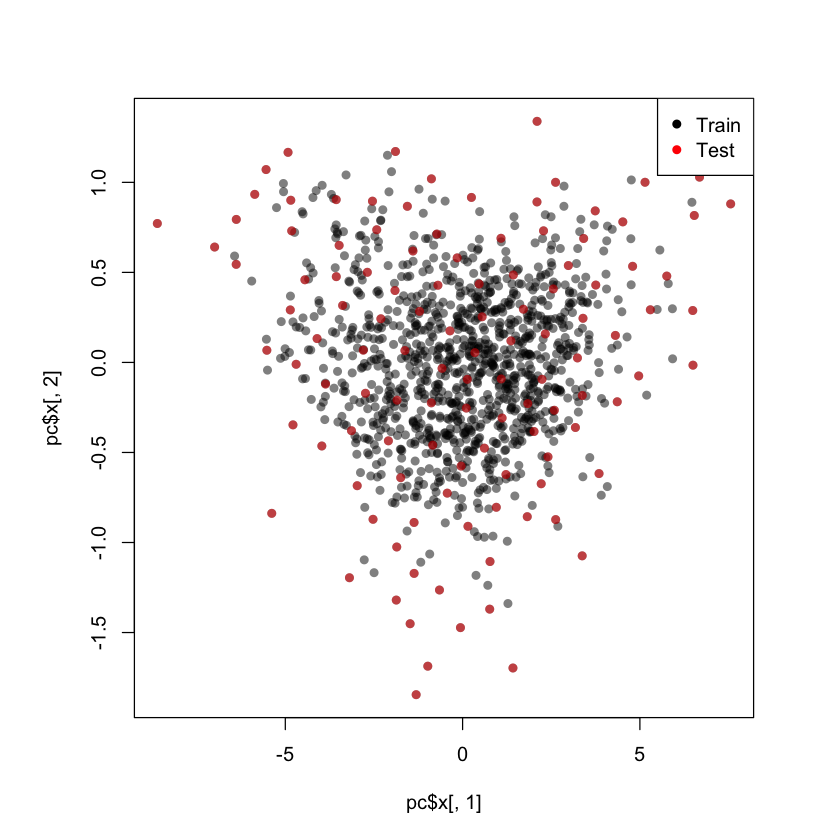

In [9]:

# split the data (no preprocessing considered yet)
nXdat<-nXr00

# first we choose 10% of the data as validation
nt <- round(0.10 * nrow(nXdat))

# then we use a PC Kennard-Stone algorithm, to choose the validation points with a high variance 
split<-kenStone(X = nXdat, 
                k = nt, 
                metric="mahal",
                pc=0.95,   # based on PC feature space explaining 95% of overall variance of the spectra
                .center = TRUE,
                .scale = FALSE)


# which samples are defined as test set
test<-split$model

# which samples are defined as calibration set
train<-split$test # the naming is a bit confusing but is part of the function -> test is the rest of the data which was not considered in the kennard algorithm

# Plot in PC feature space
pc<-prcomp(nXdat, center=T, scale. = F, rank. = 5)

par(pty="s")      # pty="s" ---> squared plot, regardless of the plot window size
matplot(pc$x[,1],   # scores of first PC
        pc$x[,2],   # scores of second PC
        pch=16,
        col=adjustcolor("black", alpha.f=0.5))     # filled points

# adding test set
matpoints(pc$x[test,1], # only test set samples, 1st PC
          pc$x[test,2], # only test set samples, 2nd PC
          pch=16, 
          col=adjustcolor("red", alpha.f=0.5))

# Legend
legend("topright", legend=c("Train","Test"), 
       col=c("black","red"), pch=16)

In [10]:
# how many PCs are considered in our case? does the plot show the whole feature space?

pca <- prcomp(nXdat, center = TRUE, scale. = FALSE)
var_explained <- pca$sdev^2 / sum(pca$sdev^2)
cumvar <- cumsum(var_explained)
n_pc_95 <- which(cumvar >= 0.95)[1]

n_pc_95


[1] 2

we get 2, which is ideal in our case, so the plot shows the whole feature space with 95% variance explained

#### 5. plot the spectra of the whole lab data

In [11]:
# Define organic samples
organic <- which(lab_raw$MINERAL == "organic")
organic

[1]   20   23   31  216  219  229  290  324  350  402  611  763  764  769 1121
[16] 1148

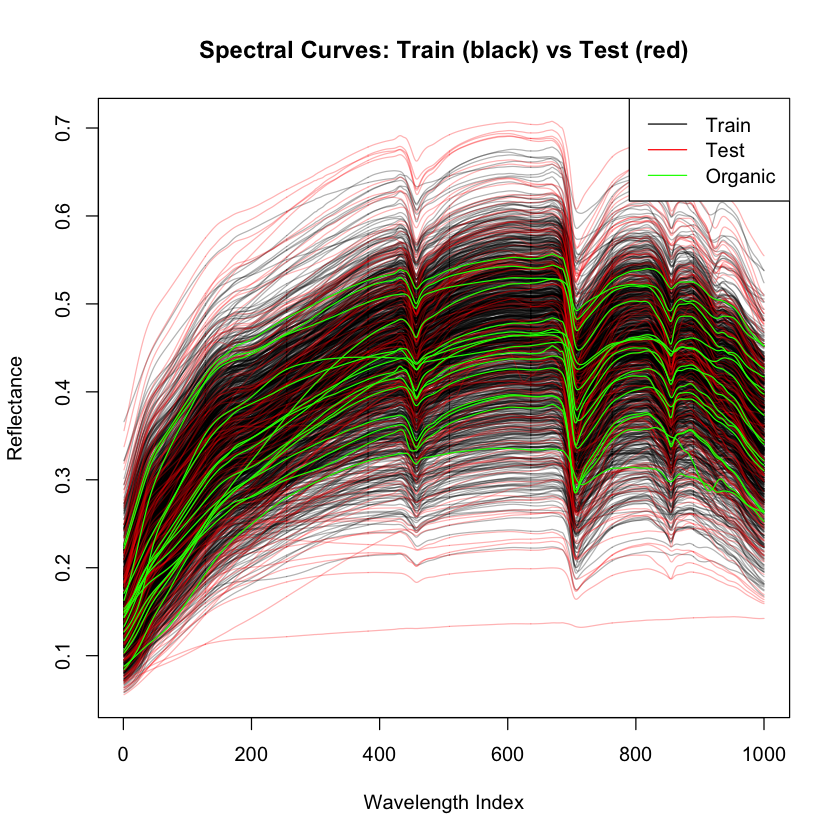

In [12]:
# Set up plot limits
ymin <- min(nXdat)
ymax <- max(nXdat)

# Plot all training spectra
matplot(t(nXdat[train, ]), type="l", lty=1, col=rgb(0,0,0,0.3),
        xlab="Wavelength Index", ylab="Reflectance", ylim=c(ymin, ymax),
        main="Spectral Curves: Train (black) vs Test (red)")

# Add test spectra
matlines(t(nXdat[test, ]), type="l", lty=1, col=rgb(1,0,0,0.3))

# Organic spectra (green)
matlines(t(nXdat[organic, ]), type="l", lty=1, col="green")

# Legend
legend("topright", legend=c("Train","Test","Organic"), 
       col=c("black","red","green"), lty=1)

# Add legend
#legend("topright", legend=c("Train","Test"), col=c("black","red"), lty=1)


#### 6. apply PLSR, without and with CV

In [13]:
# apply PLSR
nXdat<-nXr00 

Ytrain <- as.matrix(lab$SOC[train])   # calibration set
Xtrain <- as.matrix(nXdat[train,])     # calibration set

# first we calculate the Model without cross validation, to see how well it ideally could perform (best R^2 possible)
modf <- plsr(Ytrain~Xtrain,       # variables
              ncomp=20,  # max. number of latent variables to compute
              method="oscorespls",    # oscorespls = NIPALS = standard PLS
              validation="none")      # without any validation
summary(modf)

Data: 	X dimension: 1048 1000 
	Y dimension: 1048 1
Fit method: oscorespls
Number of components considered: 20
TRAINING: % variance explained
        1 comps  2 comps  3 comps  4 comps  5 comps  6 comps  7 comps  8 comps
X        93.352    96.68    98.08    99.46    99.76    99.86    99.92    99.94
Ytrain    7.545    17.75    24.02    28.07    37.63    44.16    49.02    54.98
        9 comps  10 comps  11 comps  12 comps  13 comps  14 comps  15 comps
X         99.96     99.97     99.97     99.98     99.98     99.99     99.99
Ytrain    57.22     61.43     64.38     65.41     65.72     66.26     66.67
        16 comps  17 comps  18 comps  19 comps  20 comps
X          99.99     99.99     99.99     99.99     99.99
Ytrain     66.94     67.56     67.88     68.31     68.61


In [14]:
# then we apply Model with 10-fold cross validation
set.seed(125)
modcv <- plsr(Ytrain~Xtrain,        # variables
              ncomp=20,   # max. number of latent variables to compute
              method="oscorespls",     # oscorespls = NIPALS 
              validation="CV",   # with n-fold cross-validation
              segments=10)       # n of segments = 10 --> 10-fold CV
summary(modcv)

Data: 	X dimension: 1048 1000 
	Y dimension: 1048 1
Fit method: oscorespls
Number of components considered: 20

VALIDATION: RMSEP
Cross-validated using 10 random segments.
       (Intercept)  1 comps  2 comps  3 comps  4 comps  5 comps  6 comps
CV           13.66    13.15    12.44    12.00    11.68    10.89    10.31
adjCV        13.66    13.15    12.43    11.99    11.67    10.88    10.31
       7 comps  8 comps  9 comps  10 comps  11 comps  12 comps  13 comps
CV       9.883    9.297    9.086     8.655     8.343     8.246     8.226
adjCV    9.876    9.291    9.078     8.647     8.334     8.235     8.216
       14 comps  15 comps  16 comps  17 comps  18 comps  19 comps  20 comps
CV        8.236     8.261     8.324     8.476     8.549     8.614     8.702
adjCV     8.223     8.241     8.298     8.425     8.485     8.535     8.617

TRAINING: % variance explained
        1 comps  2 comps  3 comps  4 comps  5 comps  6 comps  7 comps  8 comps
X        93.352    96.68    98.08    99.46    99.76

#### 7. Compare RMSE of no CV and CV. Choose optimal LV

13 comps 
      13

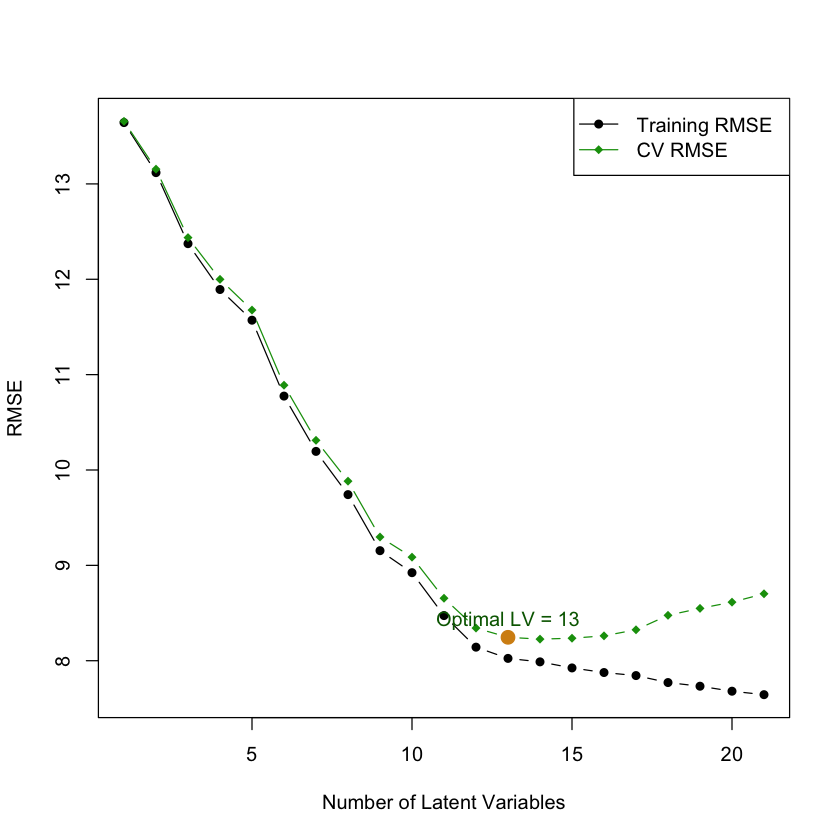

In [15]:
# RMSE of model fit
err_fit<-RMSEP(modf)

# RMSE of cross validation
err_modcv<-RMSEP(modcv)

# amount of LVs
ncomp <- 1:length(err_fit$val[1,1,])

# RMSE Training
train_rmse <- err_fit$val[1,1,]

# RMSE CV
cv_rmse <- err_modcv$val[1,1,]

# optimal amount of CV
optimal_lv <- which.min(cv_rmse) -1
optimal_lv

# Plot Training RMSE
plot(ncomp, train_rmse, type="b", col="#000000", pch=16,
     xlab="Number of Latent Variables", ylab="RMSE",
     ylim=range(c(train_rmse, cv_rmse)))

# Plot CV RMSE
lines(ncomp, cv_rmse, type="b", col="#129d0b", pch=18)

legend("topright",
       legend=c("Training RMSE", "CV RMSE"),
       col=c("#000000","#129d0b"),
       pch=c(16,18),
       lty=1)

# add optimal LV in plot
points(optimal_lv, cv_rmse[optimal_lv], col="#d48e14", pch=19, cex=1.5)
text(optimal_lv, cv_rmse[optimal_lv], labels=paste("Optimal LV =", optimal_lv),
     pos=3, col="darkgreen")

#### 8. calculate regression coefficient and scatter plot 

13 comps 
      13

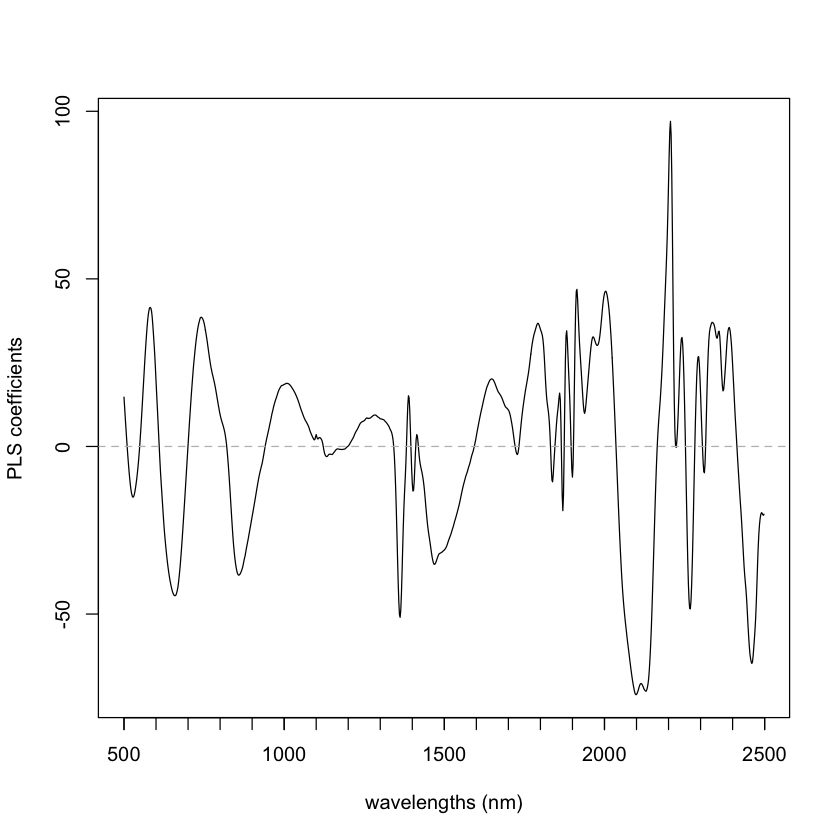

In [16]:
# choose LVs of 13 as optimal
onc<-which.min(err_modcv$val[1,,])-1      
onc
# Inspection of regression coefficients
par(pty="m")         
matplot(wl, modcv$coefficients[,,onc], type="l", lty=1,
        xlab="wavelengths (nm)", ylab="PLS coefficients")
axis(1, seq(500,2500,100), labels = NA)
abline(h=0, lty=2, col="gray")

[1] 0.64 8.23 1.66


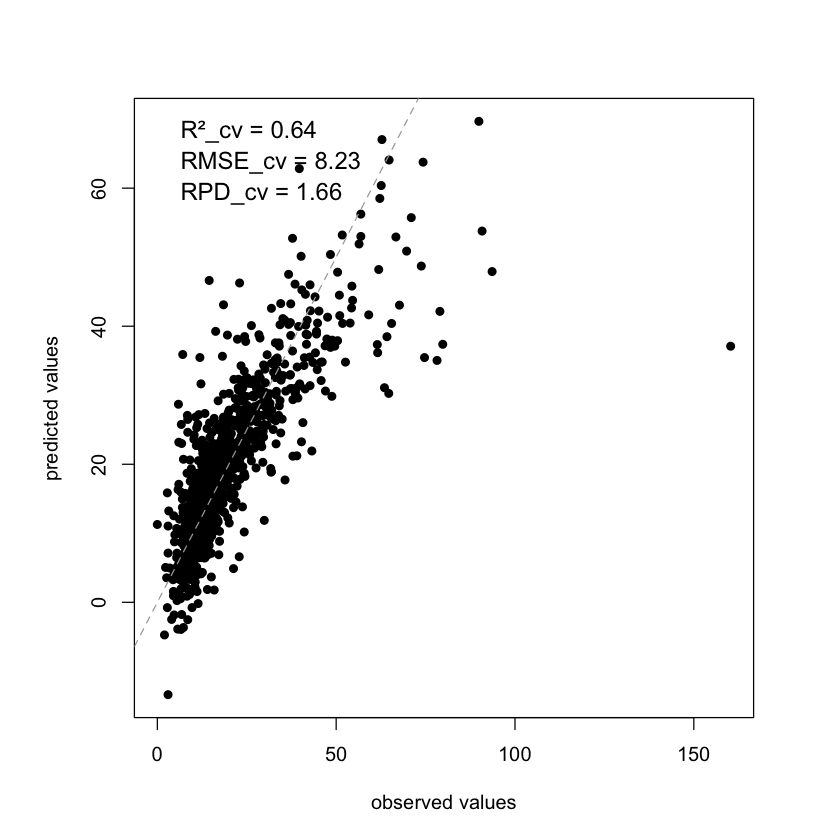

In [17]:
# scatter plot of observed vs predicted values
par(pty="s")
matplot(Ytrain,
        modcv$validation$pred[,,onc],
        xlab="observed values",
        ylab="predicted values",
        pch=16)
# adding a 1:1 line
abline(0,1, lty=2, col="darkgrey")

# validation metrics:
Yobs<-Ytrain         # observed model values
np<-nrow(Yobs)     # number of values
Ycv <- modcv$validation$pred[,,onc]

# calculation of R²:
SST<-sum((Yobs-mean(Yobs))^2)        
SSE<-sum((Ycv-Yobs)^2)
R2<-round(1-(SSE/SST), digits=2)

# calculation of RMSE
RMSE<-round(sqrt(sum((Ycv-Yobs)^2)/np), digits=2)

# Calculation of RPD
RPD<-round(sd(Yobs)/RMSE, digits=2)

print(c(R2, RMSE, RPD))

# legend
legend_text <- c(paste("R²_cv =", R2),
                 paste("RMSE_cv =", RMSE),
                 paste("RPD_cv =", RPD))
legend("topleft", legend=legend_text, bty="n", cex=1.2)

#### 9. apply on test set

[1] 0.64

[1] 12.09

[1] 1.68

[1]  0.64 12.09  1.68


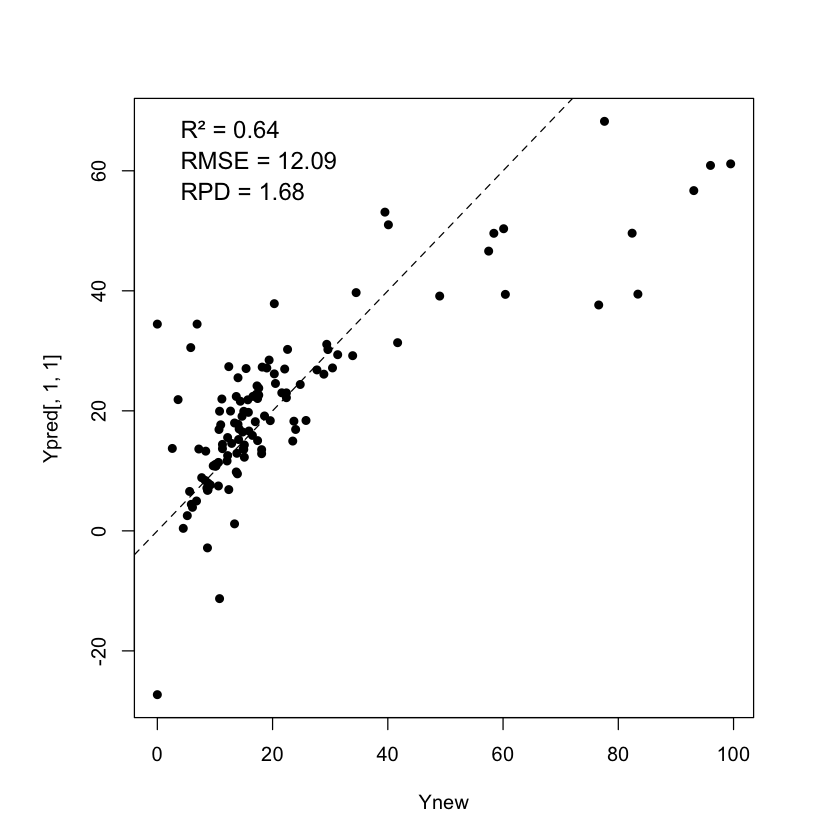

In [18]:
# Prediction on test set

Ynew <- as.matrix(lab$SOC[test])  
Xnew <- as.matrix(nXdat[test,])   

# actual prediction:
Ypred <- predict(object=modcv,   
                 ncomp=onc,       
                 newdata = Xnew)  

# Scatter plot:
par(pty="s")
matplot(Ynew, 
        Ypred[,1,1], 
        pch=16)
abline(0,1, lty=2)   # 1:1 line

# validation metrics:
np<-nrow(Ynew)     # number of predictions

# calculation of R²:
SST<-sum((Ynew-mean(Ynew))^2)        
SSE<-sum((Ynew-Ypred[,1,1])^2)
R2<-round(1-(SSE/SST), digits=2)
R2

# calculation of RMSE
RMSE<-round(sqrt(sum((Ypred[,1,1]-Ynew)^2)/np), digits=2)
RMSE

# Calculation of RPD
RPD<-round(sd(Ynew)/RMSE, digits=2)
RPD

print(c(R2, RMSE, RPD))

# text for the legend
legend_text <- c(paste("R² =", R2),
                 paste("RMSE =", RMSE),
                 paste("RPD =", RPD))

# legend
legend("topleft", legend=legend_text, bty="n", cex=1.2)


#### 11. Compare PLSR results for the preprocessing types

In [19]:
str(lab$SOC)
head(lab$SOC)

dim(nXr00)
dim(nXr01)

length(train)
length(test)

 num [1:1164] 35.1 62.6 15.1 25.8 37.3 29.6 16.9 26.3 23.2 22.9 ...


[1] 35.1 62.6 15.1 25.8 37.3 29.6

[1] 1164 1000

[1] 1164 1000

[1] 1048

[1] 116

In [20]:
preprocessing_list <- list(
  raw = nXr00,
  norm_div_mean = nXr01,
  SNV = nXr02,
  detrend = nXr03,
  SG1st_deriv = nXr04,
  mean_centered = nXr05
)

results <- data.frame(
  preprocessing = character(),
  optimal_LV = integer(),
  RMSE_CV = numeric(),
  R2_CV = numeric(),
  RMSE_test = numeric(),
  R2_test = numeric(),
  RPD_test = numeric(),
  stringsAsFactors = FALSE
)

for(name in names(preprocessing_list)){
  
  Xmat <- preprocessing_list[[name]]
  
  # Convert train set to data.frame and name columns
  Xtrain <- as.data.frame(Xmat[train, ])
  colnames(Xtrain) <- paste0("V", 1:ncol(Xtrain))
  
  # Response vector
  Ytrain <- lab$SOC[train]
  
  # Build formula for PLSR
  fmla <- as.formula(paste("Ytrain ~", paste(colnames(Xtrain), collapse=" + ")))
  
  # Fit PLSR with 10-fold CV
  set.seed(123)
  mod <- plsr(fmla, data=Xtrain, ncomp=20, method="oscorespls",
              validation="CV", segments=10)
  
  # CV RMSE
  rmse_cv <- RMSEP(mod)$val[1,1,]
  
  # Optimal number of latent variables (subtract 1 for correct indexing)
  optimal_lv_idx <- which.min(rmse_cv)
  optimal_lv <- optimal_lv_idx - 1
  
  # # Check dimensions for debugging
  # cat("RMSE CV length:", length(rmse_cv), "\n")
  # cat("Pred array dimensions:", dim(mod$validation$pred), "\n")
  # cat("Optimal LV index:", optimal_lv_idx, "Optimal LV:", optimal_lv, "\n")
  
  # CV predictions (vector only) - ensure index doesn't exceed prediction array bounds
  pred_idx <- min(optimal_lv_idx, dim(mod$validation$pred)[3])
  Ypred_cv <- mod$validation$pred[,, pred_idx]
  
  # CV R²
  SST <- sum((Ytrain - mean(Ytrain))^2)
  SSE <- sum((Ytrain - Ypred_cv)^2)
  R2_cv <- 1 - SSE/SST
  
  # Test set evaluation
  Xtest <- as.data.frame(Xmat[test, ])
  colnames(Xtest) <- paste0("V", 1:ncol(Xtest))
  Ytest <- lab$SOC[test]
  
  # Predict on test set
  Ypred_test <- predict(mod, newdata = Xtest, ncomp = optimal_lv)
  Ypred_test <- as.vector(Ypred_test)  # Convert to vector
  
  # Test set metrics
  SST_test <- sum((Ytest - mean(Ytest))^2)
  SSE_test <- sum((Ytest - Ypred_test)^2)
  R2_test <- 1 - SSE_test/SST_test
  RMSE_test <- sqrt(mean((Ytest - Ypred_test)^2))
  RPD_test <- sd(Ytest)/RMSE_test
  
  # Save results
  results <- rbind(results, data.frame(
    preprocessing=name,
    optimal_LV=optimal_lv,
    RMSE_CV=round(rmse_cv[optimal_lv_idx],3),
    R2_CV=round(R2_cv,3),
    RMSE_test=round(RMSE_test,3),
    R2_test=round(R2_test,3),
    RPD_test=round(RPD_test,3)
  ))
}

print(results)

          preprocessing optimal_LV RMSE_CV R2_CV RMSE_test R2_test RPD_test
13 comps            raw         13   8.263 0.632    12.092   0.642    1.680
13 comps1 norm_div_mean         13   8.043 0.651    11.016   0.703    1.844
14 comps            SNV         14   8.296 0.627    12.564   0.614    1.616
20 comps        detrend         20   8.657 0.597    14.279   0.501    1.422
15 comps    SG1st_deriv         15   8.154 0.637    10.923   0.708    1.859
13 comps2 mean_centered         13   8.278 0.631    12.326   0.628    1.648


#### Analysis of Preprocessing Methods Performance

**Best Performance:** **Savitzky-Golay 1st derivative (SG1st_deriv)** shows the best overall performance:
- Highest test R² (0.708) and lowest RMSE (10.923)  
- Best RPD value (1.859) for practical SOC prediction
- Good generalization (R2_CV=0.637 vs R2_test=0.708)

#### 11. Combination of Preprocessing methods

Given that mean normalization and smoothing via the 1st derivative both lead to better results with a number of latent vectors of around 14, we further investigate the combination of the two preprocessing steps. The other preprocessing methods did not improve the performance, so they are neglected in the folllowing analysis.

In [21]:
library(prospectr)
library(pls)

# --- 1. Define the Wrappers with Error Handling ---

# Normalization (Division)
apply_norm <- function(X, w) list(X = sweep(X, 1, rowMeans(X), FUN = "/"), w = w)

# SNV
apply_snv <- function(X, w) list(X = standardNormalVariate(X), w = w)

# Mean Centering (Subtraction)
apply_mcenter <- function(X, w) list(X = sweep(X, 1, rowMeans(X), FUN = "-"), w = w)

# Detrend (Fixes the dimnames error by ensuring wl matches X columns)
apply_detrend <- function(X, w) {
  # If columns were reduced by SG, we must subset the wavelength vector
  if(ncol(X) != length(w)) {
    # This assumes SG trimmed equally from both sides
    diff <- (length(w) - ncol(X)) / 2
    w_trimmed <- w[(diff + 1):(length(w) - diff)]
  } else {
    w_trimmed <- w
  }
  list(X = detrend(X, w_trimmed), w = w_trimmed)
}

# Savitzky-Golay 1st Deriv
apply_sg1 <- function(X, w) {
  X_new <- savitzkyGolay(X, m = 1, p = 2, w = 5)
  # SG reduces ncol by (w - 1). We must track the new wavelength subset.
  # w=5 means 2 columns lost at start, 2 at end.
  diff <- (ncol(X) - ncol(X_new)) / 2
  w_new <- w[(diff + 1):(length(w) - diff)]
  list(X = X_new, w = w_new)
}

# --- 2. Create the Logical Pipeline List ---

# We define the categories
scatter <- list(None = NULL, Norm = apply_norm, SNV = apply_snv, MCenter = apply_mcenter)
base    <- list(None = NULL, Detrend = apply_detrend)
deriv   <- list(None = NULL, SG1 = apply_sg1)

# Generate all valid paths: Scatter -> Baseline -> Derivative
combo_list <- list()

for (s_name in names(scatter)) {
  for (b_name in names(base)) {
    for (d_name in names(deriv)) {
      
      # Skip if everything is "None" (that's just raw data)
      if (s_name == "None" && b_name == "None" && d_name == "None") next
      
      current_data <- nXr00
      current_wl   <- wl
      name_parts   <- c()
      
      # Step 1: Scatter
      if (s_name != "None") {
        res <- scatter[[s_name]](current_data, current_wl)
        current_data <- res$X ; current_wl <- res$w
        name_parts <- c(name_parts, s_name)
      }
      # Step 2: Baseline
      if (b_name != "None") {
        res <- base[[b_name]](current_data, current_wl)
        current_data <- res$X ; current_wl <- res$w
        name_parts <- c(name_parts, b_name)
      }
      # Step 3: Derivative
      if (d_name != "None") {
        res <- deriv[[d_name]](current_data, current_wl)
        current_data <- res$X ; current_wl <- res$w
        name_parts <- c(name_parts, d_name)
      }
      
      combo_name <- paste(name_parts, collapse = " + ")
      combo_list[[combo_name]] <- current_data
    }
  }
}

# --- 3. Loop over all combinations (Same logic as before) ---

results_all <- data.frame()

for(combo_name in names(combo_list)){
  Xmat <- combo_list[[combo_name]]
  
  Xtrain <- as.data.frame(Xmat[train, ])
  colnames(Xtrain) <- paste0("V", 1:ncol(Xtrain))
  Ytrain <- lab$SOC[train]
  
  set.seed(123)
  # Using . to include all columns automatically
  mod <- plsr(Ytrain ~ ., data=Xtrain, ncomp=20, method="oscorespls", validation="CV", segments=10)
  
  rmse_cv <- RMSEP(mod)$val[1,1,]
  opt_lv  <- which.min(rmse_cv) - 1
  
  Xtest <- as.data.frame(Xmat[test, ])
  colnames(Xtest) <- paste0("V", 1:ncol(Xtest))
  Ytest <- lab$SOC[test]
  
  Ypred <- as.vector(predict(mod, newdata = Xtest, ncomp = opt_lv))
  
  RMSE_t <- sqrt(mean((Ytest - Ypred)^2))
  R2_t   <- 1 - (sum((Ytest - Ypred)^2) / sum((Ytest - mean(Ytest))^2))
  RPD_t  <- sd(Ytest) / RMSE_t
  
  results_all <- rbind(results_all, data.frame(
    preprocessing = combo_name,
    optimal_LV = opt_lv,
    RMSE_test = round(RMSE_t, 3),
    R2_test = round(R2_t, 3),
    RPD_test = round(RPD_t, 3)
  ))
}

results_all <- results_all[order(-results_all$R2_test), ]
print(results_all)

                    preprocessing optimal_LV RMSE_test R2_test RPD_test
14 comps1              Norm + SG1         14     9.222   0.792    2.202
13 comps1               SNV + SG1         13    10.603   0.725    1.915
15 comps                      SG1         15    10.923   0.708    1.859
15 comps1           MCenter + SG1         15    10.923   0.708    1.859
13 comps                     Norm         13    11.016   0.703    1.844
14 comps            Detrend + SG1         14    11.743   0.663    1.729
14 comps2    Norm + Detrend + SG1         14    11.743   0.663    1.729
14 comps4     SNV + Detrend + SG1         14    11.743   0.663    1.729
14 comps5 MCenter + Detrend + SG1         14    11.743   0.663    1.729
13 comps2                 MCenter         13    12.326   0.628    1.648
14 comps3                     SNV         14    12.564   0.614    1.616
20 comps                  Detrend         20    14.279   0.501    1.422
20 comps1          Norm + Detrend         20    14.279   0.501  

#### 12. Compare RF results for the preprocessing types

In [22]:
# Compare Random Forest results for different preprocessing types

rf_results <- data.frame(
  preprocessing = character(),
  RMSE_OOB = numeric(),
  R2_OOB = numeric(),
  RMSE_test = numeric(),
  R2_test = numeric(),
  RPD_test = numeric(),
  stringsAsFactors = FALSE
)

for(name in names(preprocessing_list)){
  
  Xmat <- preprocessing_list[[name]]
  
  # Training set
  Xtrain <- as.data.frame(Xmat[train, ])
  Ytrain <- lab$SOC[train]
  
  # Test set  
  Xtest <- as.data.frame(Xmat[test, ])
  Ytest <- lab$SOC[test]
  
  # Fit Random Forest model
  set.seed(123)
  rf_mod <- randomForest(x = Xtrain, y = Ytrain, 
                         ntree = 500, 
                         importance = TRUE)
  
  # OOB performance (built-in cross-validation equivalent)
  oob_predictions <- rf_mod$predicted
  
  # OOB R²
  SST_oob <- sum((Ytrain - mean(Ytrain))^2)
  SSE_oob <- sum((Ytrain - oob_predictions)^2)
  R2_oob <- 1 - SSE_oob/SST_oob
  
  # OOB RMSE
  RMSE_oob <- sqrt(mean((Ytrain - oob_predictions)^2))
  
  # Test set predictions
  Ypred_test <- predict(rf_mod, newdata = Xtest)
  
  # Test set metrics
  SST_test <- sum((Ytest - mean(Ytest))^2)
  SSE_test <- sum((Ytest - Ypred_test)^2)
  R2_test <- 1 - SSE_test/SST_test
  RMSE_test <- sqrt(mean((Ytest - Ypred_test)^2))
  RPD_test <- sd(Ytest)/RMSE_test
  
  # Save results
  rf_results <- rbind(rf_results, data.frame(
    preprocessing = name,
    RMSE_OOB = round(RMSE_oob, 3),
    R2_OOB = round(R2_oob, 3),
    RMSE_test = round(RMSE_test, 3),
    R2_test = round(R2_test, 3),
    RPD_test = round(RPD_test, 3)
  ))
}

print("Random Forest Results:")
print(rf_results)

[1] "Random Forest Results:"
  preprocessing RMSE_OOB R2_OOB RMSE_test R2_test RPD_test
1           raw   11.298  0.314    17.697   0.234    1.148
2 norm_div_mean    9.778  0.486    14.599   0.479    1.391
3           SNV    9.795  0.485    12.978   0.588    1.565
4       detrend    9.188  0.546    11.931   0.652    1.702
5   SG1st_deriv    8.292  0.631    13.637   0.545    1.489
6 mean_centered   10.207  0.440    14.949   0.453    1.359


#### Analysis of Random Forest Results

**Best Performance:** **Detrend** preprocessing shows the best overall RF performance:
- Highest test R² (0.652) and lowest RMSE (11.931)  
- Best RPD value (1.702) - indicating "fair" model useful for screening
- Good OOB performance (R2_OOB=0.546) suggests stable model

**Key Difference from PLSR:** Unlike PLSR where SG1st_deriv was best, RF performs better with **detrend** preprocessing. This suggests different algorithms benefit from different spectral preprocessing approaches.

**RPD Interpretation:** RPD = 1.702 means the model's prediction error is ~1.7 times smaller than the natural variability in SOC values. This falls in the "fair" category (1.4-2.0), making it useful for rough screening but not precise quantitative prediction.

**RF vs PLSR:** Detrend-RF (R²=0.652) vs SG1st_deriv-PLSR (R²=0.708) - PLSR shows superior performance for SOC prediction in this dataset.

#### Try combinations of preprocessing methods

In [23]:
# --- 1. Use the pre-defined wrappers from the previous step ---
# (Assumes apply_norm, apply_snv, apply_mcenter, apply_detrend, and apply_sg1 are in memory)

# --- 2. Setup the Logical Combinations list ---
scatter <- list(None = NULL, Norm = apply_norm, SNV = apply_snv, MCenter = apply_mcenter)
base    <- list(None = NULL, Detrend = apply_detrend)
deriv   <- list(None = NULL, SG1 = apply_sg1)

combo_list_rf <- list()

for (s_name in names(scatter)) {
  for (b_name in names(base)) {
    for (d_name in names(deriv)) {
      
      current_data <- nXr00
      current_wl   <- wl
      name_parts   <- c()
      
      if (s_name != "None") {
        res <- scatter[[s_name]](current_data, current_wl)
        current_data <- res$X ; current_wl <- res$w
        name_parts <- c(name_parts, s_name)
      }
      if (b_name != "None") {
        res <- base[[b_name]](current_data, current_wl)
        current_data <- res$X ; current_wl <- res$w
        name_parts <- c(name_parts, b_name)
      }
      if (d_name != "None") {
        res <- deriv[[d_name]](current_data, current_wl)
        current_data <- res$X ; current_wl <- res$w
        name_parts <- c(name_parts, d_name)
      }
      
      combo_name <- if(length(name_parts) == 0) "Raw" else paste(name_parts, collapse = " + ")
      combo_list_rf[[combo_name]] <- current_data
    }
  }
}

# --- 3. Run Random Forest Loop ---

rf_results_combos <- data.frame()

for(name in names(combo_list_rf)){
  
  Xmat <- combo_list_rf[[name]]
  
  # Prepare Train/Test sets
  Xtrain <- as.data.frame(Xmat[train, ])
  Ytrain <- lab$SOC[train]
  Xtest <- as.data.frame(Xmat[test, ])
  Ytest <- lab$SOC[test]
  
  # Fit Random Forest
  set.seed(123)
  rf_mod <- randomForest(x = Xtrain, y = Ytrain, 
                         ntree = 500, 
                         importance = TRUE)
  
  # OOB (Out-of-Bag) Performance
  oob_predictions <- rf_mod$predicted
  RMSE_oob <- sqrt(mean((Ytrain - oob_predictions)^2))
  R2_oob   <- 1 - (sum((Ytrain - oob_predictions)^2) / sum((Ytrain - mean(Ytrain))^2))
  
  # Test Set Performance
  Ypred_test <- predict(rf_mod, newdata = Xtest)
  RMSE_test  <- sqrt(mean((Ytest - Ypred_test)^2))
  R2_test    <- 1 - (sum((Ytest - Ypred_test)^2) / sum((Ytest - mean(Ytest))^2))
  RPD_test   <- sd(Ytest) / RMSE_test
  
  # Save results
  rf_results_combos <- rbind(rf_results_combos, data.frame(
    preprocessing = name,
    RMSE_OOB = round(RMSE_oob, 3),
    R2_OOB = round(R2_oob, 3),
    RMSE_test = round(RMSE_test, 3),
    R2_test = round(R2_test, 3),
    RPD_test = round(RPD_test, 3)
  ))
}

# --- 4. Final Output ---
rf_results_combos <- rf_results_combos[order(-rf_results_combos$R2_test), ]
print("Random Forest Results (All Logical Combinations):")
print(rf_results_combos)

[1] "Random Forest Results (All Logical Combinations):"
             preprocessing RMSE_OOB R2_OOB RMSE_test R2_test RPD_test
4            Detrend + SG1    8.265  0.633    11.319   0.687    1.794
8     Norm + Detrend + SG1    8.265  0.633    11.319   0.687    1.794
12     SNV + Detrend + SG1    8.265  0.633    11.319   0.687    1.794
16 MCenter + Detrend + SG1    8.265  0.633    11.319   0.687    1.794
10               SNV + SG1    8.659  0.597    11.756   0.662    1.727
3                  Detrend    9.188  0.546    11.931   0.652    1.702
7           Norm + Detrend    9.188  0.546    11.931   0.652    1.702
11           SNV + Detrend    9.188  0.546    11.931   0.652    1.702
15       MCenter + Detrend    9.188  0.546    11.931   0.652    1.702
9                      SNV    9.795  0.485    12.978   0.588    1.565
6               Norm + SG1    8.424  0.619    13.034   0.585    1.558
2                      SG1    8.292  0.631    13.637   0.545    1.489
14           MCenter + SG1    8.29

#### 10. Apply filters eg. by land cover type

The soil samples are distributed over a large area and were samples from different land covers and might thus be very heterogenous. Isolating soil samples for different land covers might improve the performance of the model. In the following script, for each Land Cover type (LC1) an own model is trained and validated. For simplicity, the best performing pre-processing pipelines of the previous scripts are used to train the models.

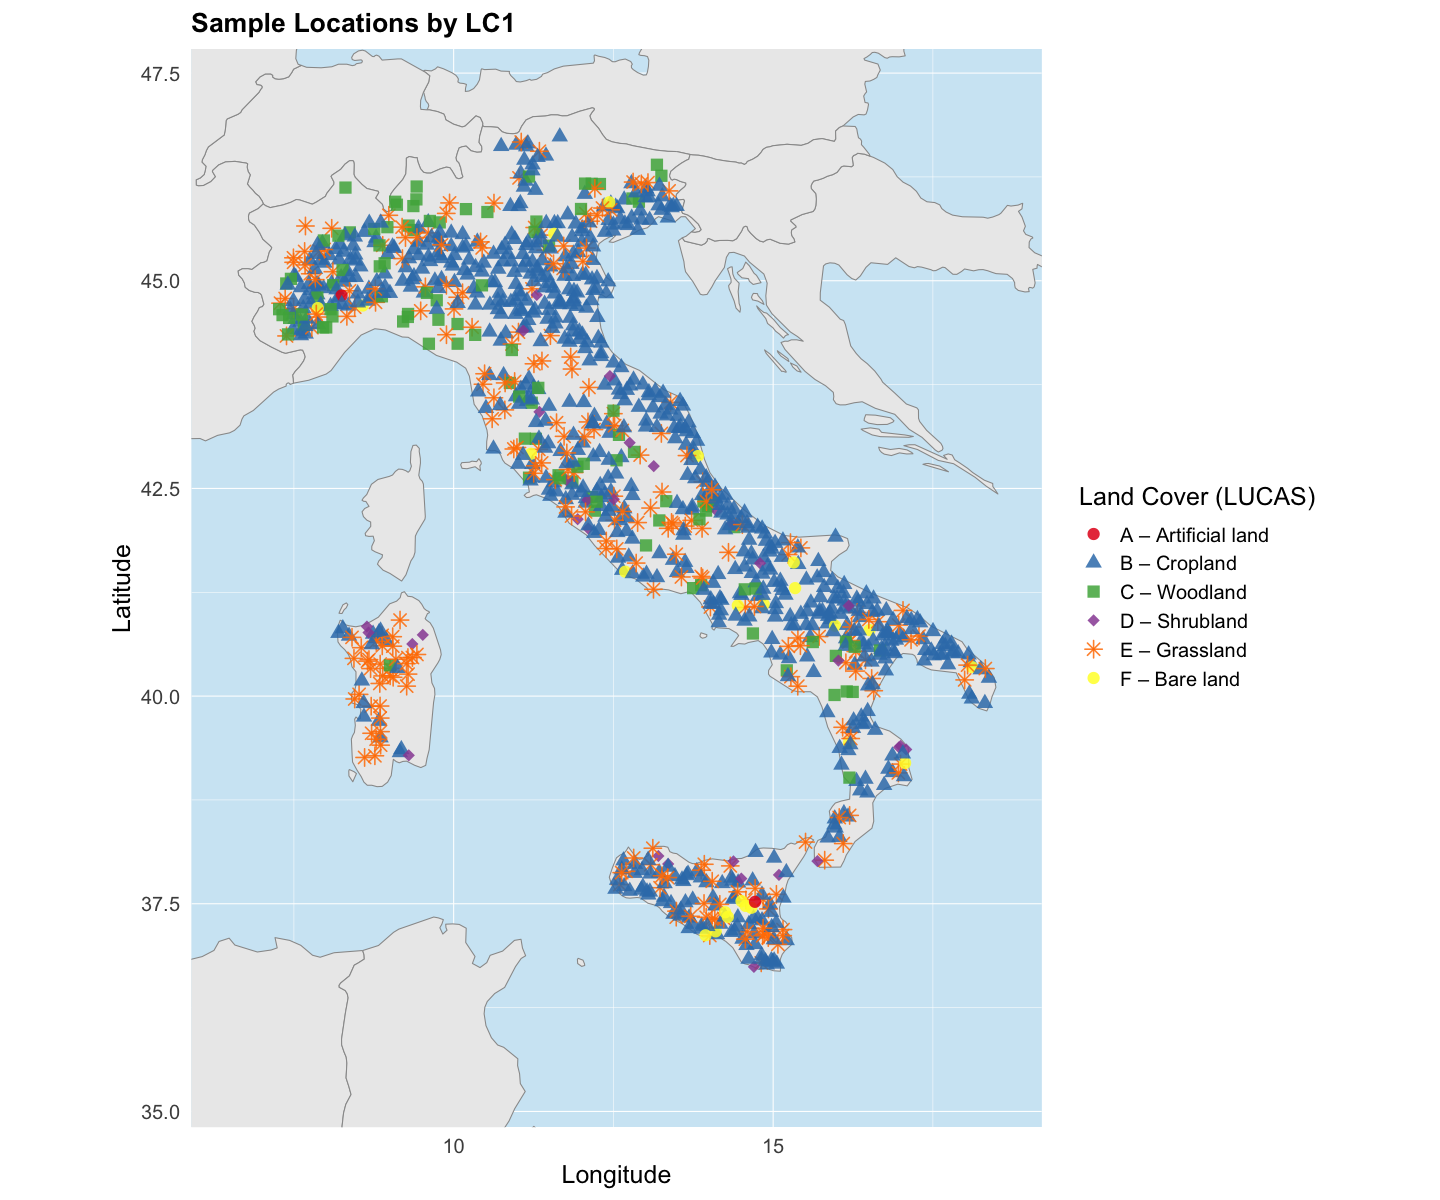

In [24]:
library(maps)
library(ggplot2)
library(RColorBrewer)

# ---- SETTINGS ----
lc_column  <- "LC1"   # change to "LC2", "LU1", or "LU2"
plot_width  <- 12     # inches
plot_height <- 10     # inches
# --------------------------------

italy_map <- map_data("world", region = c("Italy", "France", "Switzerland",
                                           "Austria", "Slovenia", "Croatia",
                                           "Tunisia", "Algeria"))

# LUCAS level-1 legend
lucas_legend <- c(
  "A" = "Artificial land",
  "B" = "Cropland",
  "C" = "Woodland",
  "D" = "Shrubland",
  "E" = "Grassland",
  "F" = "Bare land",
  "G" = "Water",
  "H" = "Wetlands"
)

lc_values  <- substr(dat_all[[lc_column]], 1, 1)
lc_groups  <- sort(unique(lc_values))
n_classes  <- length(lc_groups)
colors     <- brewer.pal(min(n_classes, 9), "Set1")
if (n_classes > 9) colors <- colorRampPalette(colors)(n_classes)
names(colors) <- lc_groups

# Labels for groups present in data
legend_labels <- paste0(lc_groups, " – ", lucas_legend[lc_groups])
names(legend_labels) <- lc_groups

p <- ggplot() +
  geom_polygon(
    data      = italy_map,
    aes(x = long, y = lat, group = group),
    fill      = "grey92",
    color     = "grey60",
    linewidth = 0.3
  ) +
  geom_point(
    data  = dat_all,
    aes(x = GPS_LONG, y = GPS_LAT, color = lc_values, shape = lc_values),
    size  = 3,
    alpha = 0.85
  ) +
  coord_fixed(ratio = 1.3, xlim = c(6.5, 18.6), ylim = c(35.4, 47.2)) +
  scale_color_manual(
    values = colors,
    labels = legend_labels,
    name   = "Land Cover (LUCAS)"
  ) +
  scale_shape_manual(
    values = rep(c(16, 17, 15, 18, 8), length.out = n_classes),
    labels = legend_labels,
    name   = "Land Cover (LUCAS)"
  ) +
  theme_minimal(base_size = 15) +
  theme(
    panel.background = element_rect(fill = "#d0e8f5", color = NA),
    panel.grid       = element_line(color = "white", linewidth = 0.3),
    legend.position  = "right",
    plot.title       = element_text(size = 16, face = "bold")
  ) +
  labs(
    title = paste("Sample Locations by", lc_column),
    x = "Longitude", y = "Latitude"
  )

options(repr.plot.width = plot_width, repr.plot.height = plot_height)
print(p)

In [25]:
# Identify spectral columns (adjust this pattern to match your data)
spec_cols <- grep("^X[0-9]", colnames(dat_all), value = TRUE)
wl <- as.numeric(sub("X", "", spec_cols))  # wavelength vector

# Initialize results table
results <- data.frame(
  LC = character(),
  model = character(),
  n_train = integer(),
  n_test = integer(),
  optimal_LV = numeric(),
  RMSE_CV_OOB = numeric(),
  R2_CV_OOB = numeric(),
  RMSE_test = numeric(),
  R2_test = numeric(),
  RPD_test = numeric(),
  stringsAsFactors = FALSE
)

# Land cover classes — grouped by first letter
dat_all$LC1_group <- substr(dat_all$LC1, 1, 1)
lcs <- unique(dat_all$LC1_group)
print(lcs)

for (lc in lcs) {
  cat("\n========== Land Cover Group:", lc, "==========\n")
  
  # Subset data for this land cover group
  lc_dat <- dat_all[dat_all$LC1_group == lc, ]
  cat("N samples:", nrow(lc_dat), "\n")
  
  # Skip if too few samples for meaningful modelling
  if (nrow(lc_dat) < 20) {
    cat("Skipping", lc, "— too few samples.\n")
    next
  }
  
  # Extract spectral matrix and response
  Xmat_full <- as.matrix(lc_dat[, spec_cols])
  SOC_full  <- lc_dat$SOC  # adjust column name if needed
  
  # ---- Kennard-Stone split (10% as test) ----
  nt <- max(2, round(0.20 * nrow(lc_dat)))
  split <- kenStone(
    X       = Xmat_full,
    k       = nt,
    metric  = "mahal",
    pc      = 0.95,
    .center = TRUE,
    .scale  = FALSE
  )
  # prospectr convention: $model = selected (calibration), $test = remainder
  # Here we want 10% as TEST, so we use $model as test indices
  test  <- split$model   # the nt selected samples → test set
  train <- split$test    # the remainder           → training set
  
  cat("Train:", length(train), "| Test:", length(test), "\n")

  # ================================================================
  # ===== PLSR model — preprocessing: Mean Normalization + SG1 =====
  # ================================================================
  
  # 1. Apply preprocessing pipeline to full matrix, tracking wavelengths
  plsr_result <- apply_norm(Xmat_full, wl)   # mean normalization
  plsr_result <- apply_sg1(plsr_result$X, plsr_result$w)  # SG 1st derivative
  
  Xmat_plsr <- plsr_result$X   # preprocessed spectral matrix
  wl_plsr   <- plsr_result$w   # updated wavelength vector (trimmed by SG)
  
  # 2. Split into train / test AFTER preprocessing
  Xtrain_plsr <- as.data.frame(Xmat_plsr[train, ])
  Xtest_plsr  <- as.data.frame(Xmat_plsr[test,  ])
  colnames(Xtrain_plsr) <- paste0("V", 1:ncol(Xtrain_plsr))
  colnames(Xtest_plsr)  <- paste0("V", 1:ncol(Xtest_plsr))
  
  Ytrain <- SOC_full[train]
  Ytest  <- SOC_full[test]
  
  # 3. Fit PLSR with 10-fold CV
  fmla <- as.formula(paste("Ytrain ~", paste(colnames(Xtrain_plsr), collapse = " + ")))
  
  set.seed(123)
  mod <- plsr(fmla,
              data       = Xtrain_plsr,
              ncomp      = min(20, length(train) - 1),
              method     = "oscorespls",
              validation = "CV",
              segments   = 10)
  
  # 4. Optimal number of LVs via CV RMSE
  rmse_cv       <- RMSEP(mod)$val[1, 1, ]   # intercept + ncomp values
  optimal_lv_idx <- which.min(rmse_cv)
  optimal_lv     <- optimal_lv_idx - 1      # subtract 1: index 1 = 0 components
  
  # 5. CV predictions & metrics
  pred_idx    <- min(optimal_lv_idx, dim(mod$validation$pred)[3])
  Ypred_cv    <- as.vector(mod$validation$pred[, , pred_idx])
  R2_cv       <- 1 - sum((Ytrain - Ypred_cv)^2) / sum((Ytrain - mean(Ytrain))^2)
  RMSE_cv_val <- rmse_cv[optimal_lv_idx]
  
  # 6. Test set predictions & metrics
  Ypred_test_plsr <- as.vector(predict(mod, newdata = Xtest_plsr, ncomp = max(1, optimal_lv)))
  R2_test_plsr    <- 1 - sum((Ytest - Ypred_test_plsr)^2) / sum((Ytest - mean(Ytest))^2)
  RMSE_test_plsr  <- sqrt(mean((Ytest - Ypred_test_plsr)^2))
  RPD_test_plsr   <- sd(Ytest) / RMSE_test_plsr
  
  # 7. Store PLSR results
  results <- rbind(results, data.frame(
    LC             = lc,
    model          = "PLSR",
    n_train        = length(train),
    n_test         = length(test),
    optimal_LV     = optimal_lv,
    RMSE_CV_OOB    = round(RMSE_cv_val, 3),
    R2_CV_OOB      = round(R2_cv, 3),
    RMSE_test      = round(RMSE_test_plsr, 3),
    R2_test        = round(R2_test_plsr, 3),
    RPD_test       = round(RPD_test_plsr, 3),
    stringsAsFactors = FALSE
  ))
  
  # ================================================================
  # ===== RF model — preprocessing: Detrend + SG1 =================
  # ================================================================
  
  # 1. Apply preprocessing pipeline
  rf_result <- apply_detrend(Xmat_full, wl)          # detrend
  rf_result <- apply_sg1(rf_result$X, rf_result$w)   # SG 1st derivative
  
  Xmat_rf <- rf_result$X
  # wl_rf <- rf_result$w   # available if needed
  
  # 2. Split (same train/test indices as PLSR for fair comparison)
  Xtrain_rf <- as.data.frame(Xmat_rf[train, ])
  Xtest_rf  <- as.data.frame(Xmat_rf[test,  ])
  # Keep same Ytrain / Ytest from above
  
  # 3. Fit Random Forest
  set.seed(123)
  rf_mod <- randomForest(
    x          = Xtrain_rf,
    y          = Ytrain,
    ntree      = 500,
    importance = TRUE
  )
  
  # 4. OOB performance
  oob_predictions <- rf_mod$predicted
  R2_oob   <- 1 - sum((Ytrain - oob_predictions)^2) / sum((Ytrain - mean(Ytrain))^2)
  RMSE_oob <- sqrt(mean((Ytrain - oob_predictions)^2))
  
  # 5. Test set predictions & metrics
  Ypred_test_rf <- predict(rf_mod, newdata = Xtest_rf)
  R2_test_rf    <- 1 - sum((Ytest - Ypred_test_rf)^2) / sum((Ytest - mean(Ytest))^2)
  RMSE_test_rf  <- sqrt(mean((Ytest - Ypred_test_rf)^2))
  RPD_test_rf   <- sd(Ytest) / RMSE_test_rf
  
  # 6. Store RF results
  results <- rbind(results, data.frame(
    LC             = lc,
    model          = "RF",
    n_train        = length(train),
    n_test         = length(test),
    optimal_LV     = NA,   # not applicable for RF
    RMSE_CV_OOB    = round(RMSE_oob, 3),
    R2_CV_OOB      = round(R2_oob, 3),
    RMSE_test      = round(RMSE_test_rf, 3),
    R2_test        = round(R2_test_rf, 3),
    RPD_test       = round(RPD_test_rf, 3),
    stringsAsFactors = FALSE
  ))
}

# ================================================================
# ===== Summary table with overall averages ======================
# ================================================================

avg_row_plsr <- data.frame(
  LC             = "AVERAGE",
  model          = "PLSR",
  n_train        = round(mean(results$n_train[results$model == "PLSR"])),
  n_test         = round(mean(results$n_test[results$model == "PLSR"])),
  optimal_LV     = round(mean(results$optimal_LV[results$model == "PLSR"], na.rm = TRUE), 1),
  RMSE_CV_OOB    = round(mean(results$RMSE_CV_OOB[results$model == "PLSR"]), 3),
  R2_CV_OOB      = round(mean(results$R2_CV_OOB[results$model == "PLSR"]), 3),
  RMSE_test      = round(mean(results$RMSE_test[results$model == "PLSR"]), 3),
  R2_test        = round(mean(results$R2_test[results$model == "PLSR"]), 3),
  RPD_test       = round(mean(results$RPD_test[results$model == "PLSR"]), 3),
  stringsAsFactors = FALSE
)

avg_row_rf <- data.frame(
  LC             = "AVERAGE",
  model          = "RF",
  n_train        = round(mean(results$n_train[results$model == "RF"])),
  n_test         = round(mean(results$n_test[results$model == "RF"])),
  optimal_LV     = NA,
  RMSE_CV_OOB    = round(mean(results$RMSE_CV_OOB[results$model == "RF"]), 3),
  R2_CV_OOB      = round(mean(results$R2_CV_OOB[results$model == "RF"]), 3),
  RMSE_test      = round(mean(results$RMSE_test[results$model == "RF"]), 3),
  R2_test        = round(mean(results$R2_test[results$model == "RF"]), 3),
  RPD_test       = round(mean(results$RPD_test[results$model == "RF"]), 3),
  stringsAsFactors = FALSE
)

results_final <- rbind(results, avg_row_plsr, avg_row_rf)

print(results_final)

[1] "B" "C" "E" "F" "A" "D"

========== Land Cover Group: B ==========
N samples: 755 
Train: 604 | Test: 151 

========== Land Cover Group: C ==========
N samples: 104 
Train: 83 | Test: 21 

========== Land Cover Group: E ==========
N samples: 249 
Train: 199 | Test: 50 

========== Land Cover Group: F ==========
N samples: 23 
Train: 18 | Test: 5 


Warning message in pls::mvr(fmla, data = Xtrain_plsr, ncomp = min(20, length(train) - :
“`ncomp' reduced to 15 due to cross-validation”



========== Land Cover Group: A ==========
N samples: 2 
Skipping A — too few samples.

========== Land Cover Group: D ==========
N samples: 31 
Train: 25 | Test: 6 
              LC model n_train n_test optimal_LV RMSE_CV_OOB R2_CV_OOB
6 comps        B  PLSR     604    151        6.0       8.186     0.475
1              B    RF     604    151         NA       8.112     0.491
2 comps        C  PLSR      83     21        2.0      12.471     0.561
11             C    RF      83     21         NA      13.865     0.508
13 comps       E  PLSR     199     50       13.0       7.413     0.699
12             E    RF     199     50         NA       8.835     0.580
2 comps1       F  PLSR      18      5        2.0       5.848     0.010
13             F    RF      18      5         NA       5.889     0.099
3 comps        D  PLSR      25      6        3.0       8.858     0.171
14             D    RF      25      6         NA       8.341     0.297
15       AVERAGE  PLSR     186     47        5.2     

Training models on each land cover class did not lead to better results. Especially for land cover classes with small sample sizes, the models fail to estimate the soil content and are further not able to generalize to unseen data.

#### Adding Meta Data as Features

As a further strategy, we add the meta data as predictors to estimate the SOC content

#### Correlations of meta data with SOC content

In [26]:
# Prepare empty result table
results <- data.frame(
  Variable = character(),
  Correlation_with_SOC = numeric(),
  Test_Type = character(),
  stringsAsFactors = FALSE
)

# Numeric columns
numeric_cols <- c("CLAY","SILT","SAND","CaCO3","N","P","K","CEC","GPS_LAT","GPS_LONG")

for (col in numeric_cols) {
  corr <- cor(dat_all[[col]], dat_all$SOC, use = "complete.obs")
  results[nrow(results) + 1, ] <- list(col, round(corr, 3), "Pearson")
}

# Categorical columns
categorical_cols <- c("LC1","LC2","LU1","LU2")

for (col in categorical_cols) {
  formula <- as.formula(paste("SOC ~", col))
  aov_result <- aov(formula, data = dat_all)
  anova_table <- summary(aov_result)[[1]]
  
  # Extract sum of squares as numeric
  ss_between <- as.numeric(anova_table["Sum Sq"][1, 1])
  ss_total <- sum(as.numeric(anova_table[,"Sum Sq"]))
  eta <- sqrt(ss_between / ss_total)
  
  results[nrow(results) + 1, ] <- list(col, round(eta, 3), "ANOVA (eta)")
}

# View table
print(results)

   Variable Correlation_with_SOC   Test_Type
1      CLAY               -0.019     Pearson
2      SILT                0.024     Pearson
3      SAND               -0.003     Pearson
4     CaCO3               -0.022     Pearson
5         N                0.927     Pearson
6         P                0.181     Pearson
7         K                0.036     Pearson
8       CEC                0.327     Pearson
9   GPS_LAT                0.158     Pearson
10 GPS_LONG               -0.093     Pearson
11      LC1                0.425 ANOVA (eta)
12      LC2                0.134 ANOVA (eta)
13      LU1                0.351 ANOVA (eta)
14      LU2                0.181 ANOVA (eta)


We can see that the variables <br>
- N (numerical)
- CEC (numerical)
- LC1 (categorical)
- LU1 (categorical) <br>

exhibit a correlation of above 0.3, so they are considered in the further analysis. The categorical variables are only added to the random forest model (Land Cover/Land use), since PLSR does only make sense with numerical features.

#### PLSR

Train: 25 | Test: 6 
Features: 998 ( 996 spectral + N + CEC )


Warning message in pls::mvr(Ytrain ~ ., data = Xtrain, ncomp = 24, validation = "CV", :
“`ncomp' reduced to 21 due to cross-validation”


Optimal LVs: 10 
         preprocessing optimal_LV RMSE_test R2_test RPD_test
1 Norm + SG1 + N + CEC         10     10.98   0.594    1.719


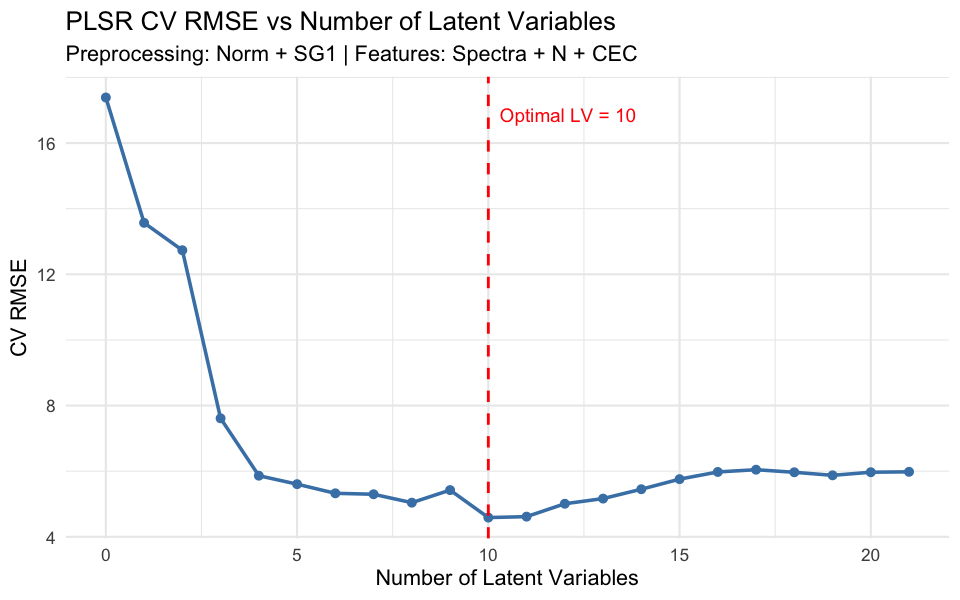

In [32]:
# ================================================================
# PLSR with Spectra (Norm + SG1) + N + CEC
# ================================================================

library(prospectr)
library(pls)

# --- 1. Apply best preprocessing: Norm + SG1 to spectra only ---
res <- apply_norm(nXr00, wl)
res <- apply_sg1(res$X, res$w)

Xspec    <- res$X
wl_new   <- res$w

# --- 2. Scale N and CEC using training set statistics only ---
N_raw   <- lab$N
CEC_raw <- lab$CEC

N_mean   <- mean(N_raw[train],   na.rm = TRUE)
N_sd     <- sd(N_raw[train],     na.rm = TRUE)
CEC_mean <- mean(CEC_raw[train], na.rm = TRUE)
CEC_sd   <- sd(CEC_raw[train],   na.rm = TRUE)

N_scaled   <- (N_raw   - N_mean)   / N_sd
CEC_scaled <- (CEC_raw - CEC_mean) / CEC_sd

# --- 3. Merge spectra + N + CEC ---
Xmat <- cbind(Xspec, N = N_scaled, CEC = CEC_scaled)

# --- 4. Split using existing train/test indices ---
Xtrain <- as.data.frame(Xmat[train, ])
colnames(Xtrain) <- paste0("V", 1:ncol(Xtrain))
Ytrain <- lab$SOC[train]

Xtest <- as.data.frame(Xmat[test, ])
colnames(Xtest) <- paste0("V", 1:ncol(Xtest))
Ytest <- lab$SOC[test]

cat("Train:", nrow(Xtrain), "| Test:", nrow(Xtest), "\n")
cat("Features:", ncol(Xtrain), "(", ncol(Xspec), "spectral + N + CEC )\n")

# --- 5. Fit PLSR ---
set.seed(123)
mod <- plsr(Ytrain ~ ., data = Xtrain, ncomp = 24,
            method = "oscorespls", validation = "CV", segments = 10)

# --- 6. Optimal LVs ---
rmse_cv <- RMSEP(mod)$val[1, 1, ]
opt_lv  <- max(1, which.min(rmse_cv) - 1)

cat("Optimal LVs:", opt_lv, "\n")

# --- 7. Test set predictions & metrics ---
Ypred <- as.vector(predict(mod, newdata = Xtest, ncomp = opt_lv))

RMSE_t <- sqrt(mean((Ytest - Ypred)^2))
R2_t   <- 1 - sum((Ytest - Ypred)^2) / sum((Ytest - mean(Ytest))^2)
RPD_t  <- sd(Ytest) / RMSE_t

# --- 8. Store result in same format as results_all ---
result_N_CEC <- data.frame(
  preprocessing = "Norm + SG1 + N + CEC",
  optimal_LV    = opt_lv,
  RMSE_test     = round(RMSE_t, 3),
  R2_test       = round(R2_t,   3),
  RPD_test      = round(RPD_t,  3)
)

# --- 9. Compare against all preprocessing results ---
result_N_CEC <- result_N_CEC[order(-result_N_CEC$R2_test), ]
print(result_N_CEC)

# --- 10. Plot CV RMSE vs LVs ---
lv_df <- data.frame(
  n_LV    = 0:(length(rmse_cv) - 1),
  RMSE_CV = rmse_cv
)

options(repr.plot.width = 8, repr.plot.height = 5)

ggplot(lv_df, aes(x = n_LV, y = RMSE_CV)) +
  geom_line(color = "steelblue", linewidth = 1) +
  geom_point(color = "steelblue", size = 2) +
  geom_vline(xintercept = opt_lv, color = "red",
             linetype = "dashed", linewidth = 0.8) +
  annotate("text",
           x = opt_lv + 0.3, y = max(rmse_cv) * 0.97,
           label = paste("Optimal LV =", opt_lv),
           color = "red", hjust = 0, size = 4) +
  theme_minimal(base_size = 13) +
  labs(
    title    = "PLSR CV RMSE vs Number of Latent Variables",
    subtitle = "Preprocessing: Norm + SG1 | Features: Spectra + N + CEC",
    x = "Number of Latent Variables",
    y = "CV RMSE"
  )

#### Random Forest

In [33]:
# ================================================================
# RF with Spectra (Detrend + SG1) + N + CEC + LC1 + LU1
# ================================================================

library(randomForest)

# --- 1. Apply best preprocessing: Detrend + SG1 to spectra only ---
res <- apply_detrend(nXr00, wl)
res <- apply_sg1(res$X, res$w)

Xspec  <- res$X
wl_new <- res$w

# --- 2. Scale N and CEC using training set statistics only ---
N_raw   <- lab$N
CEC_raw <- lab$CEC

N_mean   <- mean(N_raw[train],   na.rm = TRUE)
N_sd     <- sd(N_raw[train],     na.rm = TRUE)
CEC_mean <- mean(CEC_raw[train], na.rm = TRUE)
CEC_sd   <- sd(CEC_raw[train],   na.rm = TRUE)

N_scaled   <- (N_raw   - N_mean)   / N_sd
CEC_scaled <- (CEC_raw - CEC_mean) / CEC_sd

# --- 3. LC1 and LU1 as factors ---
LC1_factor <- as.factor(lab$LC1)
LU1_factor <- as.factor(lab$LU1)

# --- 4. Merge all features ---
Xmat <- cbind(
  as.data.frame(Xspec),
  N   = N_scaled,
  CEC = CEC_scaled,
  LC1 = LC1_factor,
  LU1 = LU1_factor
)

# --- 5. Train / test split ---
Xtrain <- Xmat[train, ]
Xtest  <- Xmat[test,  ]
Ytrain <- lab$SOC[train]
Ytest  <- lab$SOC[test]

cat("Train:", nrow(Xtrain), "| Test:", nrow(Xtest),
    "| Features:", ncol(Xtrain), "\n")

# --- 6. Fit Random Forest ---
set.seed(123)
rf_mod <- randomForest(x          = Xtrain,
                       y          = Ytrain,
                       ntree      = 500,
                       importance = TRUE)

# --- 7. OOB performance ---
oob_predictions <- rf_mod$predicted
RMSE_oob <- sqrt(mean((Ytrain - oob_predictions)^2))
R2_oob   <- 1 - sum((Ytrain - oob_predictions)^2) / sum((Ytrain - mean(Ytrain))^2)

# --- 8. Test set performance ---
Ypred_test <- predict(rf_mod, newdata = Xtest)
RMSE_test  <- sqrt(mean((Ytest - Ypred_test)^2))
R2_test    <- 1 - sum((Ytest - Ypred_test)^2) / sum((Ytest - mean(Ytest))^2)
RPD_test   <- sd(Ytest) / RMSE_test

# --- 9. Store result in same format as rf_results_combos ---
result_rf_features <- data.frame(
  preprocessing = "Detrend + SG1 + N + CEC + LC1 + LU1",
  RMSE_OOB  = round(RMSE_oob,  3),
  R2_OOB    = round(R2_oob,    3),
  RMSE_test = round(RMSE_test, 3),
  R2_test   = round(R2_test,   3),
  RPD_test  = round(RPD_test,  3)
)

# --- 10. Compare against all preprocessing results ---
results_combined_rf <- rbind(rf_results_combos, result_rf_features)
results_combined_rf <- results_combined_rf[order(-results_combined_rf$R2_test), ]
print(results_combined_rf)

Train: 25 | Test: 6 | Features: 1000 
                         preprocessing RMSE_OOB R2_OOB RMSE_test R2_test
17 Detrend + SG1 + N + CEC + LC1 + LU1   11.072  0.560     9.265   0.711
4                        Detrend + SG1    8.265  0.633    11.319   0.687
8                 Norm + Detrend + SG1    8.265  0.633    11.319   0.687
12                 SNV + Detrend + SG1    8.265  0.633    11.319   0.687
16             MCenter + Detrend + SG1    8.265  0.633    11.319   0.687
10                           SNV + SG1    8.659  0.597    11.756   0.662
3                              Detrend    9.188  0.546    11.931   0.652
7                       Norm + Detrend    9.188  0.546    11.931   0.652
11                       SNV + Detrend    9.188  0.546    11.931   0.652
15                   MCenter + Detrend    9.188  0.546    11.931   0.652
9                                  SNV    9.795  0.485    12.978   0.588
6                           Norm + SG1    8.424  0.619    13.034   0.585
2            

Integrating lab information to predict the SOC content can increase the prediction by around 20 percentage points.

#### Visualize contribution of Lab values

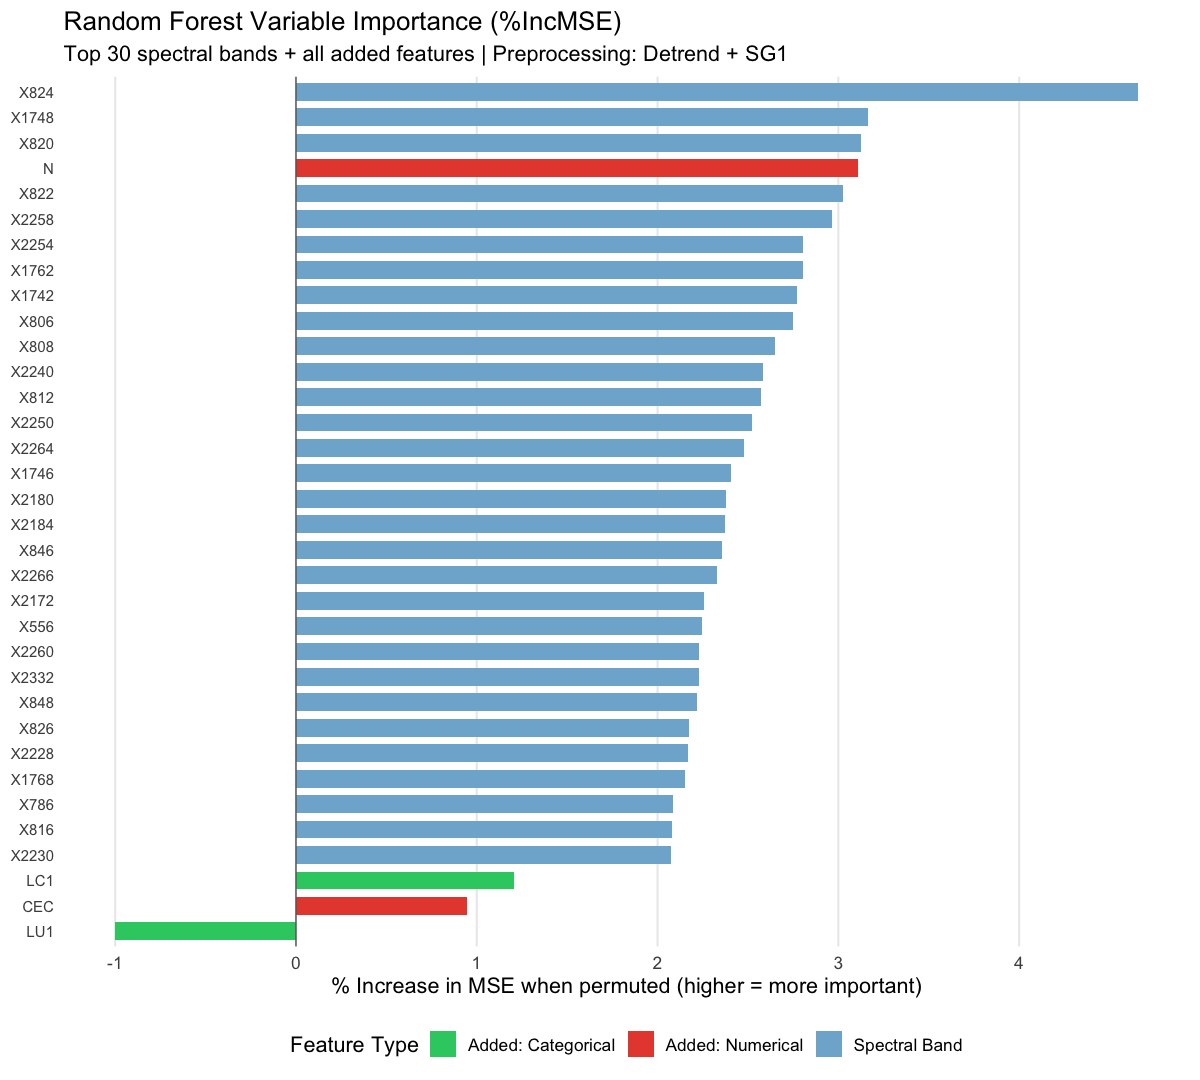

In [34]:
# --- 1. Extract importance scores — use namespace explicitly ---
imp <- randomForest::importance(rf_mod, type = 1)   # type=1 = %IncMSE

imp_df <- data.frame(
  feature = rownames(imp),
  IncMSE  = imp[, 1],
  stringsAsFactors = FALSE
)

# --- 2. Label feature groups ---
imp_df$group <- dplyr::case_when(
  imp_df$feature == "N"   ~ "Added: Numerical",
  imp_df$feature == "CEC" ~ "Added: Numerical",
  imp_df$feature == "LC1" ~ "Added: Categorical",
  imp_df$feature == "LU1" ~ "Added: Categorical",
  TRUE                     ~ "Spectral Band"
)

# --- 3. Top 30 spectral + all added features ---
top_spectral <- imp_df %>%
  dplyr::filter(group == "Spectral Band") %>%
  dplyr::slice_max(IncMSE, n = 30)

added_features <- imp_df %>%
  dplyr::filter(group != "Spectral Band")

imp_plot <- rbind(top_spectral, added_features)
imp_plot <- imp_plot[order(imp_plot$IncMSE), ]
imp_plot$feature <- factor(imp_plot$feature, levels = imp_plot$feature)

# --- 4. Plot ---
options(repr.plot.width = 10, repr.plot.height = 9)

ggplot(imp_plot, aes(x = IncMSE, y = feature, fill = group)) +
  geom_col(width = 0.7) +
  geom_vline(xintercept = 0, color = "grey40", linewidth = 0.4) +
  scale_fill_manual(
    name   = "Feature Type",
    values = c(
      "Spectral Band"      = "#7fb3d3",
      "Added: Numerical"   = "#e74c3c",
      "Added: Categorical" = "#2ecc71"
    )
  ) +
  theme_minimal(base_size = 13) +
  theme(
    legend.position    = "bottom",
    panel.grid.major.y = element_blank(),
    panel.grid.minor   = element_blank(),
    axis.text.y        = element_text(size = 9)
  ) +
  labs(
    title    = "Random Forest Variable Importance (%IncMSE)",
    subtitle = "Top 30 spectral bands + all added features | Preprocessing: Detrend + SG1",
    x        = "% Increase in MSE when permuted (higher = more important)",
    y        = NULL
  )

We can see that essentially the feature "N" and "CEC" contribute heavily to the increased performance of the random forest model. But also the land cover and land use information are considered inflential to the overall prediction error of the random forest model.